In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [3]:
train = pd.get_dummies(train, columns=["Sex"], drop_first=True)
test = pd.get_dummies(test, columns=["Sex"], drop_first=True)

In [4]:
X = train.drop(["Rings", "id"], axis=1)
y = train["Rings"]

X_test = test.drop(["id"], axis=1)

In [9]:
lr = LinearRegression()
lr.fit(X, y)

predictions_lr = lr.predict(X_test)

# Fix negative predictions
predictions_lr = np.maximum(predictions_lr, 0)

In [12]:
submission_lr = pd.DataFrame({
    "id": test["id"],
    "Rings": predictions_lr
})

submission_lr.to_csv("submission_lr.csv", index=False)

In [7]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

predictions_rf = rf.predict(X_test)

In [8]:
submission_rf = pd.DataFrame({
    "id": test["id"],
    "Rings": predictions_rf
})

submission_rf.to_csv("submission_rf.csv", index=False)
submission_rf.head()

,id,Rings
0,90615,10.165
1,90616,9.800
2,90617,10.045
3,90618,11.195
4,90619,7.830


In [13]:
# Applied Question #10 - Carseats Multiple Regression
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=1f5f43166a12acce79b74322cb267e984c03b1b14283159948a3038dcea37d81
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from ISLP import load_data
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import OLSInfluence

In [15]:
Carseats = load_data("Carseats")
Carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [16]:
model1 = smf.ols("Sales ~ Price + Urban + US", data=Carseats).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           2.39e-23
Time:                        16:49:22   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651     20.036   

In [17]:
anova_lm(model1)

,df,sum_sq,mean_sq,F,PR(>F)
Urban,1.0,0.756615,0.756615,0.123767,7.251713e-01
US,1.0,100.846148,100.846148,16.496407,5.877444e-05
Price,1.0,659.837263,659.837263,107.936143,1.609917e-22
Residual,396.0,2420.834671,6.113219,NaN,NaN


In [18]:
model2 = smf.ols("Sales ~ Price + US", data=Carseats).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           2.66e-24
Time:                        16:49:38   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0308      0.631     20.652      0.0

In [19]:
print("Model 1 R-squared:", model1.rsquared)
print("Model 1 Adjusted R-squared:", model1.rsquared_adj)
print("Model 1 AIC:", model1.aic)
print("Model 1 BIC:", model1.bic)

print()

print("Model 2 R-squared:", model2.rsquared)
print("Model 2 Adjusted R-squared:", model2.rsquared_adj)
print("Model 2 AIC:", model2.aic)
print("Model 2 BIC:", model2.bic)

Model 1 R-squared: 0.23927539218405558
Model 1 Adjusted R-squared: 0.2335123269733287
Model 1 AIC: 1863.3120738106174
Model 1 BIC: 1879.2779319990493

Model 2 R-squared: 0.23926288842678567
Model 2 Adjusted R-squared: 0.23543045965311715
Model 2 AIC: 1861.3186484129808
Model 2 BIC: 1873.2930420543048


In [20]:
model2.conf_int(alpha=0.05)

,0,1
Intercept,11.79032,14.271265
US[T.Yes],0.69152,1.707766
Price,-0.06476,-0.044195


In [21]:
influence = OLSInfluence(model2)

summary_frame = influence.summary_frame()
summary_frame[["standard_resid", "hat_diag", "cooks_d"]].head()

,standard_resid,hat_diag,cooks_d
0,0.733148,0.003922,0.000705
1,0.614748,0.009004,0.001145
2,0.076422,0.009954,0.000020
3,-0.627878,0.005636,0.000745
4,-0.775599,0.007928,0.001602


In [22]:
print("Largest absolute standardized residuals:")
print(summary_frame["standard_resid"].abs().sort_values(ascending=False).head(10))

print()
print("Largest leverage values:")
print(summary_frame["hat_diag"].sort_values(ascending=False).head(10))

print()
print("Largest Cook's distance values:")
print(summary_frame["cooks_d"].sort_values(ascending=False).head(10))

Largest absolute standardized residuals:
376    2.865082
50     2.811022
68     2.622678
25     2.581001
209    2.563363
28     2.418794
352    2.376116
57     2.335540
49     2.321404
297    2.230292
Name: standard_resid, dtype: float64

Largest leverage values:
42     0.043338
174    0.029687
165    0.028567
125    0.025966
367    0.023707
313    0.023165
171    0.021014
269    0.019195
272    0.018687
356    0.018279
Name: hat_diag, dtype: float64

Largest Cook's distance values:
25     0.026109
367    0.024287
49     0.022835
316    0.020470
165    0.019755
376    0.018282
258    0.017677
143    0.016857
30     0.015799
209    0.015663
Name: cooks_d, dtype: float64


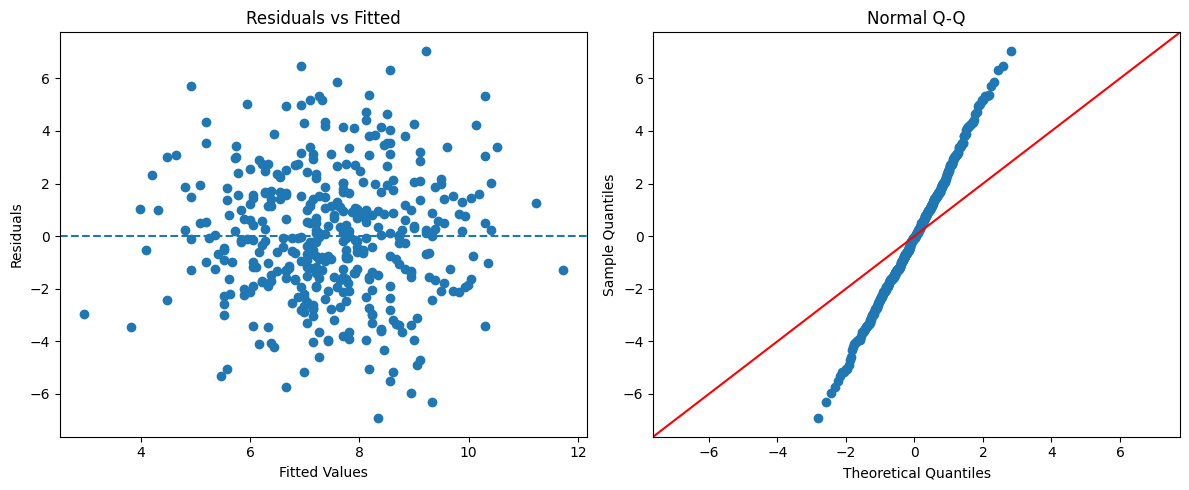

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(model2.fittedvalues, model2.resid)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(model2.resid, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q")

plt.tight_layout()
plt.show()